# S&P 500 Financial Analysis

End-to-end analysis of S&P 500 constituents including 
data cleaning, exploratory analysis, and SQL window functions.

**Dataset:** 503 companies · 14 original columns · 2017 snapshot  
**Tools:** Python · pandas · NumPy · matplotlib · seaborn · SQLite

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

## 1. Loading & First Look

In [22]:
url = "https://raw.githubusercontent.com/datasets/s-and-p-500-companies-financials/master/data/constituents-financials.csv"

df = pd.read_csv(url)
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())
print(df.nlargest(5, 'Price/Earnings')[['Symbol','Name','Sector','Price/Earnings']])
print(df.nsmallest(5, 'Price/Earnings')[['Symbol','Name','Sector','Price/Earnings']])
print(df[df['Price/Earnings'] < 0][['Symbol','Name','Sector','Price/Earnings']])

(503, 14)
  Symbol                 Name                          Sector   Price  \
0    MMM                   3M        Industrial Conglomerates  156.85   
1    AOS          A. O. Smith               Building Products   57.22   
2    ABT  Abbott Laboratories           Health Care Equipment   89.17   
3   ABBV               AbbVie                   Biotechnology  224.95   
4    ACN            Accenture  IT Consulting & Other Services  170.50   

   Price/Earnings  Dividend Yield  Earnings/Share  52 Week Low  52 Week High  \
0       30.105568          0.0200            5.21       139.34        177.41   
1       15.258667          0.0248            3.75        54.16         81.87   
2       25.550142          0.0276            3.49        81.97        139.06   
3      111.361390          0.0308            2.02       181.73        244.81   
4       14.220183          0.0382           11.99       155.82        321.77   

     Market Cap        EBITDA  Price/Sales  Price/Book  \
0  8.180783e

## 2. Data Cleaning

Three issues identified during reconnaissance:
- 15 companies missing all financial metrics (systematic missingness)
- 102 missing Dividend Yield values — filled with 0 (companies that don't pay dividends)
- Price/Earnings outliers above 100 — flagged, not removed (economic outliers, not errors)
- SEC Filings column contains URLs with no analytical value — dropped

In [23]:
df = (
    df
    .assign(
        data_quality = lambda x: np.where(x['Price'].isnull(), 'incomplete', 'ok'),
        pe_outlier   = lambda x: x['Price/Earnings'] > 100,
    )
    .fillna({'Dividend Yield': 0})
    .drop(columns=['SEC Filings'])
)
assert df.shape == (503, 15), f"Unexpected shape: {df.shape}"
assert df['Dividend Yield'].isnull().sum() == 0, "Dividend Yield still has nulls"
assert df['data_quality'].value_counts().get('incomplete', 0) == 16, "Expected 16 incomplete records"
assert df['pe_outlier'].value_counts().get(True, 0) == 19, "Expected 19 P/E outliers"
print(df.shape) 

(503, 15)


## 3. Exploratory Analysis

**Finding 1:** S&P 500 representation is highly concentrated — 
a few sub-industries like Health Care Equipment dominate with 18 companies 
while most sub-industries have only one company large enough to qualify by market cap.

**Finding 2:** Health Care REITs trade at a median P/E of 77 vs Cable & Satellite 
at 4.3 — reflecting divergent investor expectations. The market prices in strong 
earnings growth for Real Estate while Cable & Satellite faces structural decline 
from streaming substitution.

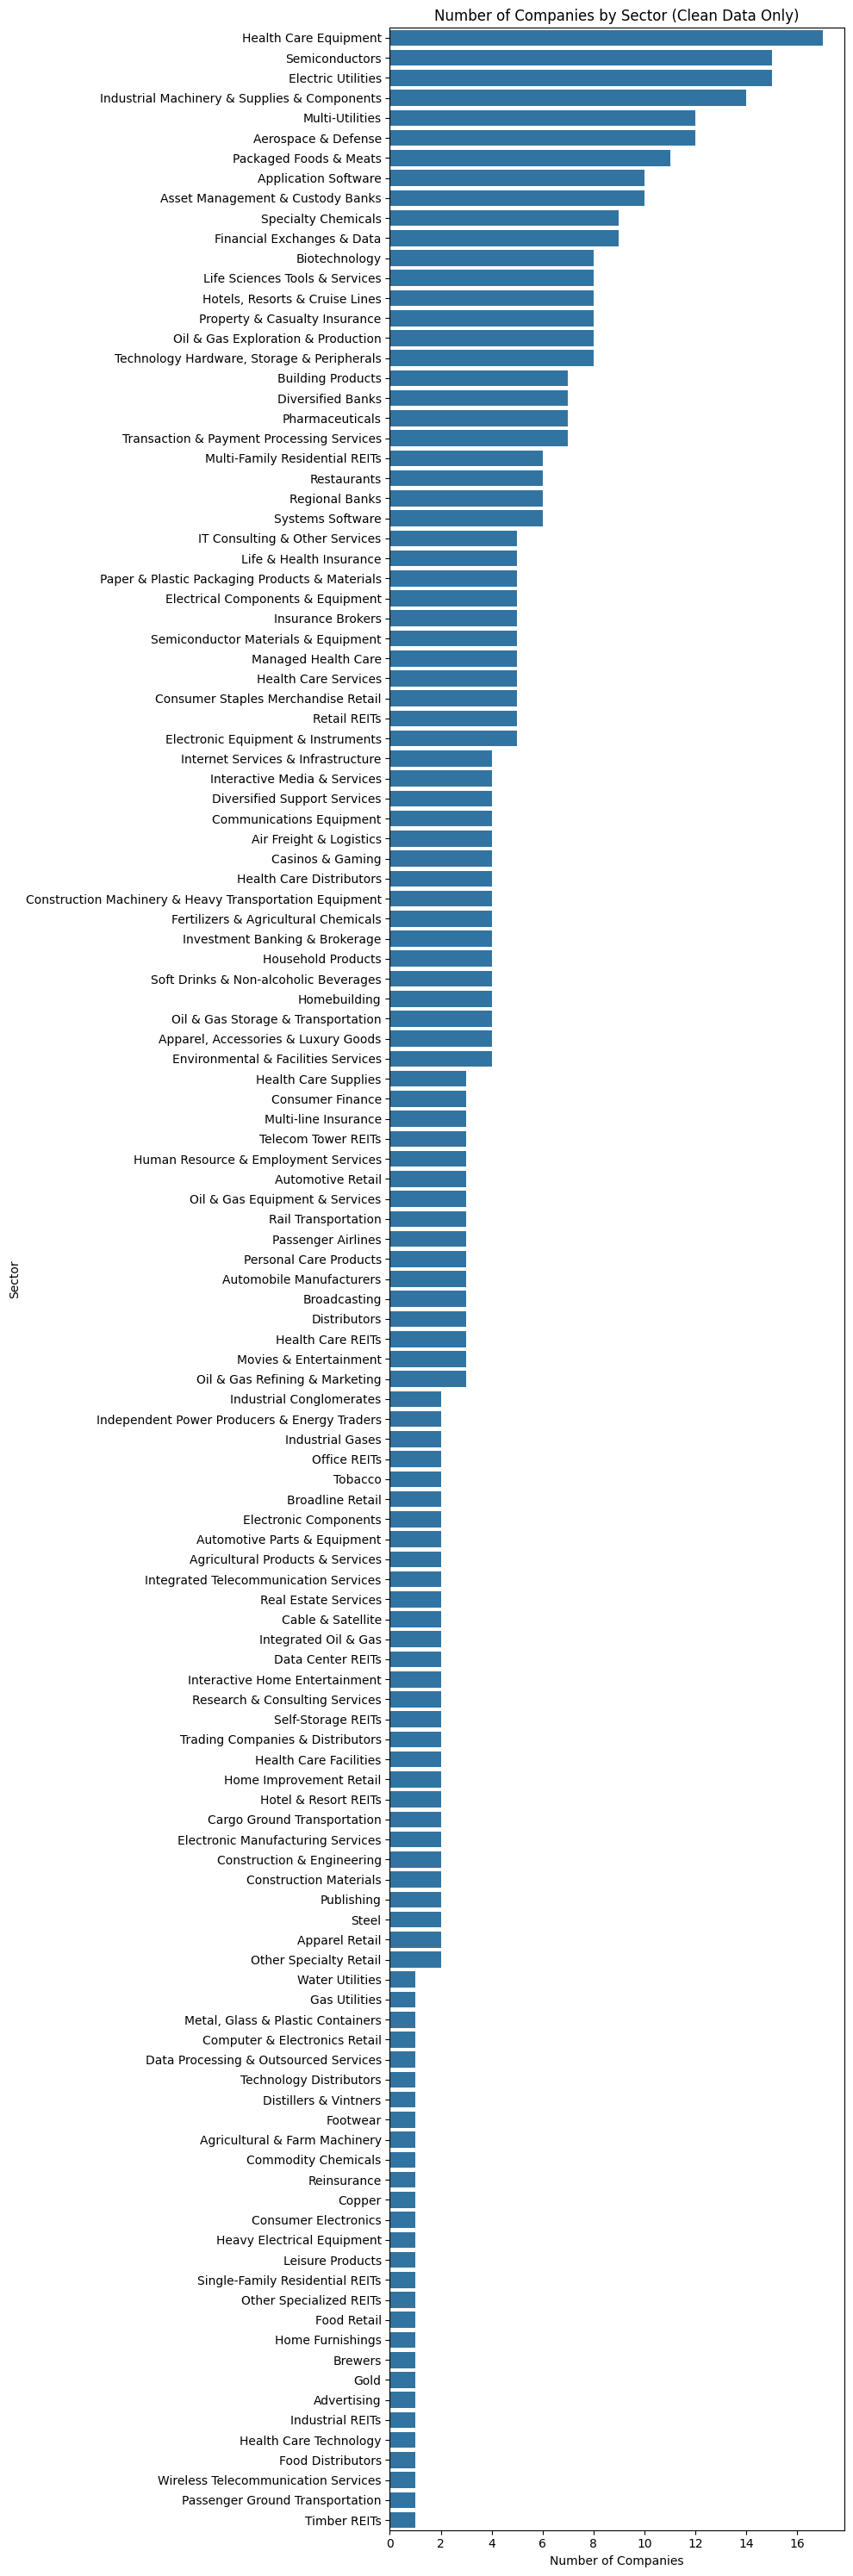

In [24]:
clean_df = df[df['data_quality'] == 'ok'].copy()
sector_counts = clean_df['Sector'].value_counts()

plt.figure(figsize=(10, 30))
sns.barplot(data=sector_counts.reset_index(), x='count', y='Sector')
plt.title('Number of Companies by Sector (Clean Data Only)')
plt.xlabel('Number of Companies')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

In [25]:
median_pe = (
    clean_df[~clean_df['pe_outlier']]
    .groupby('Sector')['Price/Earnings']
    .median()
    .reset_index()
    .rename(columns={'Price/Earnings': 'median_PE'})
    .sort_values('median_PE', ascending=False)
)
print(median_pe)

                                  Sector  median_PE
52                     Health Care REITs  63.968750
38                 Electronic Components  63.765702
23            Construction & Engineering  63.272095
30                     Data Center REITs  61.263993
108  Semiconductor Materials & Equipment  60.602720
..                                   ...        ...
17                     Cable & Satellite   4.181340
0                            Advertising        NaN
13                               Brewers        NaN
20                   Commodity Chemicals        NaN
77                      Leisure Products        NaN

[124 rows x 2 columns]


## 4. SQL Analysis

*Coming next session — 10 window function queries on sp500.db*

In [26]:
import sqlite3

conn = sqlite3.connect('sp500.db')
df.to_sql('sp500', conn, if_exists='replace', index=False)
print(f"Database created: {pd.read_sql_query('SELECT COUNT(*) as rows FROM sp500', conn).iloc[0,0]} rows loaded")

Database created: 503 rows loaded


In [27]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('sp500.db')

def sql(query):
    return pd.read_sql_query(query, conn)

# test it
sql("SELECT Symbol, Name, Sector, Price FROM sp500 LIMIT 5")

,Symbol,Name,Sector,Price
0,MMM,3M,Industrial Conglomerates,156.85
1,AOS,A. O. Smith,Building Products,57.22
2,ABT,Abbott Laboratories,Health Care Equipment,89.17
3,ABBV,AbbVie,Biotechnology,224.95
4,ACN,Accenture,IT Consulting & Other Services,170.50


## 4. SQL Analysis
Ten window function queries on the cleaned S&P 500 database.
All queries run on `sp500.db` using SQLite.

Key SQL concepts covered: ROW_NUMBER, RANK, DENSE_RANK, 
LAG, LEAD, NTILE, running totals, correlated subqueries, 
and CTE chaining.

### Query 1 — Basic Ranking by Price
Rank all S&P 500 companies by stock price descending using ROW_NUMBER().
Excludes companies with missing price data.

In [28]:
sql("""
    SELECT 
        Symbol,
        Name, 
        Sector,
        Price,
        ROW_NUMBER() OVER (ORDER BY Price DESC) AS price_rank
    FROM sp500
    WHERE Price IS NOT NULL
""")

,Symbol,Name,Sector,Price,price_rank
0,NVR,"NVR, Inc.",Homebuilding,6305.04,1
1,AZO,AutoZone,Automotive Retail,3110.05,2
2,KLAC,KLA Corporation,Semiconductor Materials & Equipment,2135.64,3
3,MPWR,Monolithic Power Systems,Semiconductors,1473.04,4
4,GWW,W. W. Grainger,Industrial Machinery & Supplies & Components,1317.63,5
...,...,...,...,...,...
482,VTRS,Viatris,Pharmaceuticals,15.77,483
483,AES,AES Corporation,Independent Power Producers & Energy Traders,14.63,484
484,F,Ford Motor Company,Automobile Manufacturers,14.30,485
485,CAG,Conagra Brands,Packaged Foods & Meats,13.34,486


### Query 2 — RANK vs ROW_NUMBER
Compare RANK and ROW_NUMBER on Price/Earnings to illustrate 
how ties are handled differently. Excludes outliers and NULLs.

In [29]:
sql("""
    SELECT
        Symbol,
        Name,
        [Price/Earnings],
        ROW_NUMBER() OVER (ORDER BY [Price/Earnings] DESC) AS rn,
        RANK() OVER (ORDER BY [Price/Earnings] DESC) AS rnk
    FROM sp500
    WHERE [Price/Earnings] IS NOT NULL AND pe_outlier = 0
    LIMIT 20
""")

,Symbol,Name,Price/Earnings,rn,rnk
0,CDNS,Cadence Design Systems,90.194380,1,1
1,PWR,Quanta Services,89.535070,2,2
2,BA,Boeing,84.615390,3,3
3,GLW,Corning Inc.,83.252470,4,4
4,GNRC,Generac,81.329930,5,5
5,ON,ON Semiconductor,81.007350,6,6
6,STX,Seagate Technology,77.125710,7,7
7,OXY,Occidental Petroleum,76.133330,8,8
8,SBUX,Starbucks,75.389320,9,9
9,TECH,Bio-Techne,75.000000,10,10


### Query 3 — Top Company per Sector by Price
Uses PARTITION BY to rank companies within each sector independently.
Returns only the most expensive stock in each sector.

In [30]:
sql("""
    WITH ranked AS (
        SELECT
            Symbol,
            Name,
            Sector,
            Price,
            ROW_NUMBER() OVER (PARTITION BY Sector ORDER BY Price DESC) AS sector_price_rank
        FROM sp500
    )
    SELECT *
    FROM ranked
    WHERE sector_price_rank = 1
""")

,Symbol,Name,Sector,Price,sector_price_rank
0,OMC,Omnicom Group,Advertising,73.98,1
1,TDG,TransDigm Group,Aerospace & Defense,1212.36,1
2,DE,Deere & Company,Agricultural & Farm Machinery,560.05,1
3,BG,Bunge Global,Agricultural Products & Services,128.21,1
4,FDX,FedEx,Air Freight & Logistics,319.25,1
...,...,...,...,...,...
122,PM,Philip Morris International,Tobacco,182.95,1
123,URI,United Rentals,Trading Companies & Distributors,1056.35,1
124,MA,Mastercard,Transaction & Payment Processing Services,489.08,1
125,AWK,American Water Works,Water Utilities,126.46,1


### Query 4 — LAG and LEAD on Market Cap
Compares each company to the one ranked above and below it by market cap.
The $725B gap between Nvidia (rank 1) and Apple (rank 2) reflects 
the AI-driven surge in Nvidia's valuation.

In [31]:
sql("""
    WITH ranked AS (
        SELECT
            Symbol,
            Name,
            "Market Cap",
            ROW_NUMBER() OVER (ORDER BY "Market Cap" DESC) AS mkt_cap_rank,
            LAG(Name, 1) OVER (ORDER BY "Market Cap" DESC) AS prev_company,
            LEAD(Name, 1) OVER (ORDER BY "Market Cap" DESC) AS next_company,
            ROUND("Market Cap" - LAG("Market Cap", 1) OVER (ORDER BY "Market Cap" DESC), 2) AS mkt_cap_diff
        FROM sp500
        WHERE "Market Cap" IS NOT NULL
    )
    SELECT *
    FROM ranked
    LIMIT 15
""")

,Symbol,Name,Market Cap,mkt_cap_rank,prev_company,next_company,mkt_cap_diff
0,NVDA,Nvidia,4.854373e+12,1,NaN,Alphabet Inc. (Class A),NaN
1,GOOGL,Alphabet Inc. (Class A),4.346031e+12,2,Nvidia,Alphabet Inc. (Class C),-5.083418e+11
2,GOOG,Alphabet Inc. (Class C),4.308714e+12,3,Alphabet Inc. (Class A),Apple Inc.,-3.731646e+10
3,AAPL,Apple Inc.,4.282539e+12,4,Alphabet Inc. (Class C),Microsoft,-2.617534e+10
4,MSFT,Microsoft,2.951763e+12,5,Apple Inc.,Amazon,-1.330776e+12
5,AMZN,Amazon,2.560192e+12,6,Microsoft,Broadcom,-3.915705e+11
6,AVGO,Broadcom,1.770296e+12,7,Amazon,Meta Platforms,-7.898965e+11
7,META,Meta Platforms,1.449389e+12,8,Broadcom,"Tesla, Inc.",-3.209067e+11
8,TSLA,"Tesla, Inc.",1.433147e+12,9,Meta Platforms,Lilly (Eli),-1.624231e+10
9,LLY,Lilly (Eli),1.013348e+12,10,"Tesla, Inc.",Micron Technology,-4.197985e+11


### Query 5 — Sector P/E Tiers with DENSE_RANK
Assigns growth tiers within each sector based on Price/Earnings.
Returns only tier 1 and 2 companies — the highest P/E names per sector.

In [32]:
sql("""
    WITH ranked AS (
        SELECT
            Symbol,
            Name,
            Sector,
            "Price/Earnings",
            DENSE_RANK() OVER (PARTITION BY Sector ORDER BY "Price/Earnings" DESC) AS tier
        FROM sp500
        WHERE "Price/Earnings" IS NOT NULL AND pe_outlier = 0
    )
    SELECT *
    FROM ranked
    WHERE tier <= 2
    ORDER BY Sector
""")

,Symbol,Name,Sector,Price/Earnings,tier
0,BA,Boeing,Aerospace & Defense,84.615390,1
1,HWM,Howmet Aerospace,Aerospace & Defense,59.544155,2
2,DE,Deere & Company,Agricultural & Farm Machinery,32.675030,1
3,ADM,Archer Daniels Midland,Agricultural Products & Services,35.649124,1
4,BG,Bunge Global,Agricultural Products & Services,33.739475,2
...,...,...,...,...,...
206,URI,United Rentals,Trading Companies & Distributors,26.968344,2
207,MA,Mastercard,Transaction & Payment Processing Services,28.303238,1
208,V,Visa Inc.,Transaction & Payment Processing Services,28.156929,2
209,AWK,American Water Works,Water Utilities,22.421986,1


### Query 6 — Running Total of Market Cap
Cumulative market cap from largest to smallest company.
Finding: the top 20 companies account for 54% of total S&P 500 
market cap — the index is heavily concentrated at the top.

In [33]:
sql("""
    WITH ranked AS (
        SELECT
            Symbol,
            Name,
            "Market Cap",
            ROW_NUMBER() OVER (ORDER BY "Market Cap" DESC) AS mkt_cap_rank,
            SUM("Market Cap") OVER (ORDER BY "Market Cap" DESC) AS running_total,
            ROUND(SUM("Market Cap") OVER (ORDER BY "Market Cap" DESC) /
                  SUM("Market Cap") OVER () * 100, 2) AS pct_of_total
        FROM sp500
        WHERE "Market Cap" IS NOT NULL
    )
    SELECT *
    FROM ranked
    WHERE mkt_cap_rank <= 20
""")

,Symbol,Name,Market Cap,mkt_cap_rank,running_total,pct_of_total
0,NVDA,Nvidia,4.854373e+12,1,4.854373e+12,7.17
1,GOOGL,Alphabet Inc. (Class A),4.346031e+12,2,9.200403e+12,13.59
2,GOOG,Alphabet Inc. (Class C),4.308714e+12,3,1.350912e+13,19.95
3,AAPL,Apple Inc.,4.282539e+12,4,1.779166e+13,26.28
4,MSFT,Microsoft,2.951763e+12,5,2.074342e+13,30.64
5,AMZN,Amazon,2.560192e+12,6,2.330361e+13,34.42
6,AVGO,Broadcom,1.770296e+12,7,2.507391e+13,37.04
7,META,Meta Platforms,1.449389e+12,8,2.652330e+13,39.18
8,TSLA,"Tesla, Inc.",1.433147e+12,9,2.795644e+13,41.29
9,LLY,Lilly (Eli),1.013348e+12,10,2.896979e+13,42.79


### Query 7 — Running Average P/E
Tracks how the cumulative average P/E evolves as we move down 
the ranking. The declining average confirms that high P/E ratios 
are concentrated in a small number of companies.

In [34]:
sql("""
    WITH ranked AS (
        SELECT
            Symbol,
            Name,
            "Price/Earnings",
            ROW_NUMBER() OVER (ORDER BY "Price/Earnings" DESC) AS pe_rank,
            ROUND(AVG("Price/Earnings") OVER (ORDER BY "Price/Earnings" DESC), 2) AS running_avg_pe
        FROM sp500
        WHERE "Price/Earnings" IS NOT NULL AND pe_outlier = 0
    )
    SELECT *
    FROM ranked
    WHERE pe_rank <= 20
""")

,Symbol,Name,Price/Earnings,pe_rank,running_avg_pe
0,CDNS,Cadence Design Systems,90.194380,1,90.19
1,PWR,Quanta Services,89.535070,2,89.86
2,BA,Boeing,84.615390,3,88.11
3,GLW,Corning Inc.,83.252470,4,86.90
4,GNRC,Generac,81.329930,5,85.79
5,ON,ON Semiconductor,81.007350,6,84.99
6,STX,Seagate Technology,77.125710,7,83.87
7,OXY,Occidental Petroleum,76.133330,8,82.90
8,SBUX,Starbucks,75.389320,9,82.06
9,TECH,Bio-Techne,75.000000,10,81.36


### Query 8 — Price/Sales Quartiles vs P/E
Buckets companies into 4 quartiles by Price/Sales using NTILE(4).
Finding: companies in the top P/S quartile have nearly double 
the average P/E of the bottom quartile — the market assigns 
high growth expectations to both multiples simultaneously.

In [35]:
sql("""
    WITH ranked AS (
        SELECT
            Symbol,
            Name,
            Sector,
            "Price/Earnings",
            NTILE(4) OVER (ORDER BY "Price/Sales" DESC) AS ps_quartile
        FROM sp500
        WHERE "Price/Sales" IS NOT NULL and pe_outlier = 0
    )
    SELECT ps_quartile,
           ROUND(AVG("Price/Earnings"), 2) AS avg_pe,
           COUNT(*) AS company_count
    FROM ranked
    GROUP BY ps_quartile
    ORDER BY ps_quartile
""")

,ps_quartile,avg_pe,company_count
0,1,37.36,117
1,2,26.61,117
2,3,22.92,117
3,4,21.30,117


### Query 9 — Companies Beating Their Sector Average Price
Correlated subquery returns companies whose price exceeds 
their sector average. Only 37% qualify — confirming that 
stock prices within sectors are right-skewed, with a few 
high-priced stocks pulling the mean above most companies.

In [36]:
sql("""
    SELECT
        Symbol,
        Name,
        Sector,
        Price
    FROM sp500 a
    WHERE Price IS NOT NULL AND "Price"> (SELECT AVG(Price) from sp500 b WHERE b.Sector = a.Sector)
    ORDER BY Sector, Price DESC
""")

,Symbol,Name,Sector,Price
0,TDG,TransDigm Group,Aerospace & Defense,1212.36
1,NOC,Northrop Grumman,Aerospace & Defense,542.14
2,LMT,Lockheed Martin,Aerospace & Defense,525.02
3,AXON,Axon Enterprise,Aerospace & Defense,447.59
4,BG,Bunge Global,Agricultural Products & Services,128.21
...,...,...,...,...
181,PM,Philip Morris International,Tobacco,182.95
182,URI,United Rentals,Trading Companies & Distributors,1056.35
183,MA,Mastercard,Transaction & Payment Processing Services,489.08
184,CPAY,Corpay,Transaction & Payment Processing Services,348.99


### Query 10 — Top 5 Sectors by Average P/E (CTE Chaining)
Chains two CTEs — sector_stats aggregates per-sector metrics, 
sector_ranked assigns P/E rankings. Returns the 5 sectors where 
the market expects the highest future earnings growth.

In [37]:
sql("""
    WITH sector_stats AS (
        SELECT
            Symbol,
            Name,
            Sector,
            ROUND(AVG("Price/Earnings"), 2) AS avg_pe,
            ROUND(AVG(Price), 2) AS avg_price,
            COUNT(*) AS company_count
        FROM sp500
        WHERE "Price/Earnings" IS NOT NULL AND pe_outlier = 0 AND Price IS NOT NULL
        GROUP BY Sector
    ),
    sector_ranked AS (
        SELECT
            Sector,
            company_count,
            avg_price,
            avg_pe,
            ROW_NUMBER() OVER (ORDER BY avg_pe DESC) AS pe_rank
        FROM sector_stats
    )
    SELECT *
    FROM sector_ranked
    WHERE pe_rank <= 5
    ORDER BY pe_rank
""")

,Sector,company_count,avg_price,avg_pe,pe_rank
0,Health Care REITs,1,20.47,63.97,1
1,Electronic Components,2,158.69,63.77,2
2,Construction & Engineering,2,386.34,63.27,3
3,Data Center REITs,2,609.55,61.26,4
4,Interactive Home Entertainment,1,203.20,58.06,5
